## Linear Regression and Gradient Descent
In this laboratory session, you will implement linear regression with gradient descent from scratch. The focus is on understanding the optimization process through hands-on implementation. You will analyze the behavior of the algorithm under different conditions and visualize the results to gain insights into the training dynamics.

### 1. Generate Synthetic Data

Generate a synthetic dataset with a known linear relationship. Create 100 data points with a single feature, using a true weight of 2 and a bias of 5, plus a small amount of Gaussian noise. This will create data that follows the relationship $y=2x+5+\epsilon$ where $\epsilon$ is random noise.

Set a random seed for reproducibility. Your feature matrix X should have shape (100, 1) and your target vector y should have shape (100,).

In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

X = np.random.rand(100, 1) * 10

weight = 2
bias = 5
noise = np.random.randn(100) #szum Gaussa

y = (weight * X.flatten()) + bias + noise
print(y.shape)
print(X.shape)

(100,)
(100, 1)


### 2. Prepare the Data

To include the bias term in our weight vector, add a column of 1s to your feature matrix X. This allows us to represent both the bias and feature weight in a single vector, simplifying our implementation.

In [8]:
ones = np.ones((100, 1))
X_bias = np.hstack((ones, X))
print(X_bias)

[[1.         3.74540119]
 [1.         9.50714306]
 [1.         7.31993942]
 [1.         5.98658484]
 [1.         1.5601864 ]
 [1.         1.5599452 ]
 [1.         0.58083612]
 [1.         8.66176146]
 [1.         6.01115012]
 [1.         7.08072578]
 [1.         0.20584494]
 [1.         9.69909852]
 [1.         8.32442641]
 [1.         2.12339111]
 [1.         1.81824967]
 [1.         1.8340451 ]
 [1.         3.04242243]
 [1.         5.24756432]
 [1.         4.31945019]
 [1.         2.9122914 ]
 [1.         6.11852895]
 [1.         1.39493861]
 [1.         2.92144649]
 [1.         3.66361843]
 [1.         4.56069984]
 [1.         7.85175961]
 [1.         1.99673782]
 [1.         5.14234438]
 [1.         5.92414569]
 [1.         0.46450413]
 [1.         6.07544852]
 [1.         1.70524124]
 [1.         0.65051593]
 [1.         9.48885537]
 [1.         9.65632033]
 [1.         8.08397348]
 [1.         3.04613769]
 [1.         0.97672114]
 [1.         6.84233027]
 [1.         4.40152494]


### 3. Initialize Parameters

Initialize your weight vector with zeros. Since we have one feature plus the bias term, your weight vector should have shape (2,), where the first element represents the bias and the second represents the feature weight.

In [9]:
theta = np.zeros(2)
print(theta.shape)

(2,)



### 4. Implement Gradient Descent
Compute the gradient (formula is provided in the introduction) and update weights.

GRADIENT

$\nabla_{\tilde{w}} L = \frac{2}{N} \tilde{X}^T (\hat{y} - y)$

Aktualizacja wag

$\tilde{w} \leftarrow \tilde{w} - \alpha \nabla_{\tilde{w}} L$


In [10]:
y_pred = X_bias @ theta
N=len(y)
gradient = (2/N) * X_bias.T @ (y_pred - y)

learning_rate = 0.1
theta = theta - learning_rate * gradient


### 5. Run the Training Loop
Put it all together to train the model. Track values of the loss function during this process. 


In [11]:
theta = np.zeros(2)
n_iterations = 1000
learning_rate = 0.01
N=len(y)
loss_history = []

for iteration in range(n_iterations):
    # 1.Calculate the Gradient
    
    y_pred = X_bias @ theta
    # Mean Squared Error Loss
    # L = (1/N) * suma((y_pred - y)^2)
    loss = (1/N) * np.sum((y_pred - y) ** 2)
    loss_history.append(loss)

    gradient = (2/N) * X_bias.T @ (y_pred - y)
    # 2.Update the Parameters
    theta = theta - learning_rate * gradient

    if iteration % 100 == 0:
        print(f"Iteration {iteration}, Loss: {loss:.4f}")  



Iteration 0, Loss: 241.6928
Iteration 100, Loss: 2.9581
Iteration 200, Loss: 1.5139
Iteration 300, Loss: 1.0391
Iteration 400, Loss: 0.8830
Iteration 500, Loss: 0.8317
Iteration 600, Loss: 0.8148
Iteration 700, Loss: 0.8093
Iteration 800, Loss: 0.8075
Iteration 900, Loss: 0.8069


### 6. Check Your Results
After training, compare your weights to the true ones. Plot the data and compare fitted model with the ground truth line.

Final parameters: [5.19665829 1.95685655]
Real parameters:  bias=5, weight=2


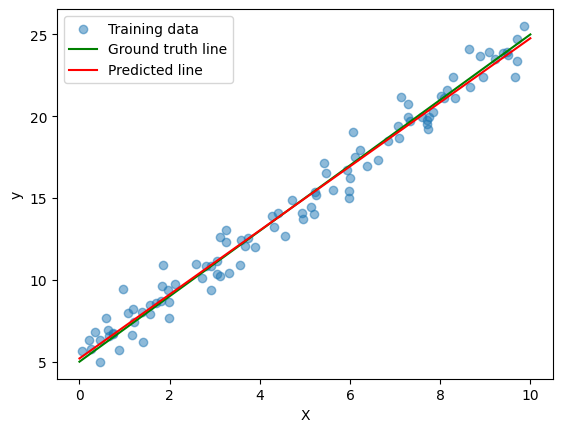

In [32]:
print(f"Final parameters: {theta}")
print(f"Real parameters:  bias={bias}, weight={weight}")


plt.scatter(X, y, alpha=0.5, label='Training data')

X_line = np.array([[0], [10]])

# Ground truth line
y_true_line = 2 * X_line + 5
plt.plot(X_line, y_true_line, color='green', label='Ground truth line')

# Predicted line
y_pred_line = theta[1] * X_line + theta[0]
plt.plot(X_line, y_pred_line, color='red', label='Predicted line')

plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()



### 7. Experiment with Learning Rate
The learning rate α controls how big of a step we take during each iteration of gradient descent. Try training your model with different learning rates: $\alpha \in [10^{-6}, 10^{-5}, 10^{-4}, 10^{-3}, 10^{-2}, 10^{-1}]$. For each value:
- Plot the loss curve (loss vs. epoch)
- Record the final weights and final loss
- Observe how quickly (or slowly) the model converges

What happens when the learning rate is too small? Too large? Is there an optimal value in this range?


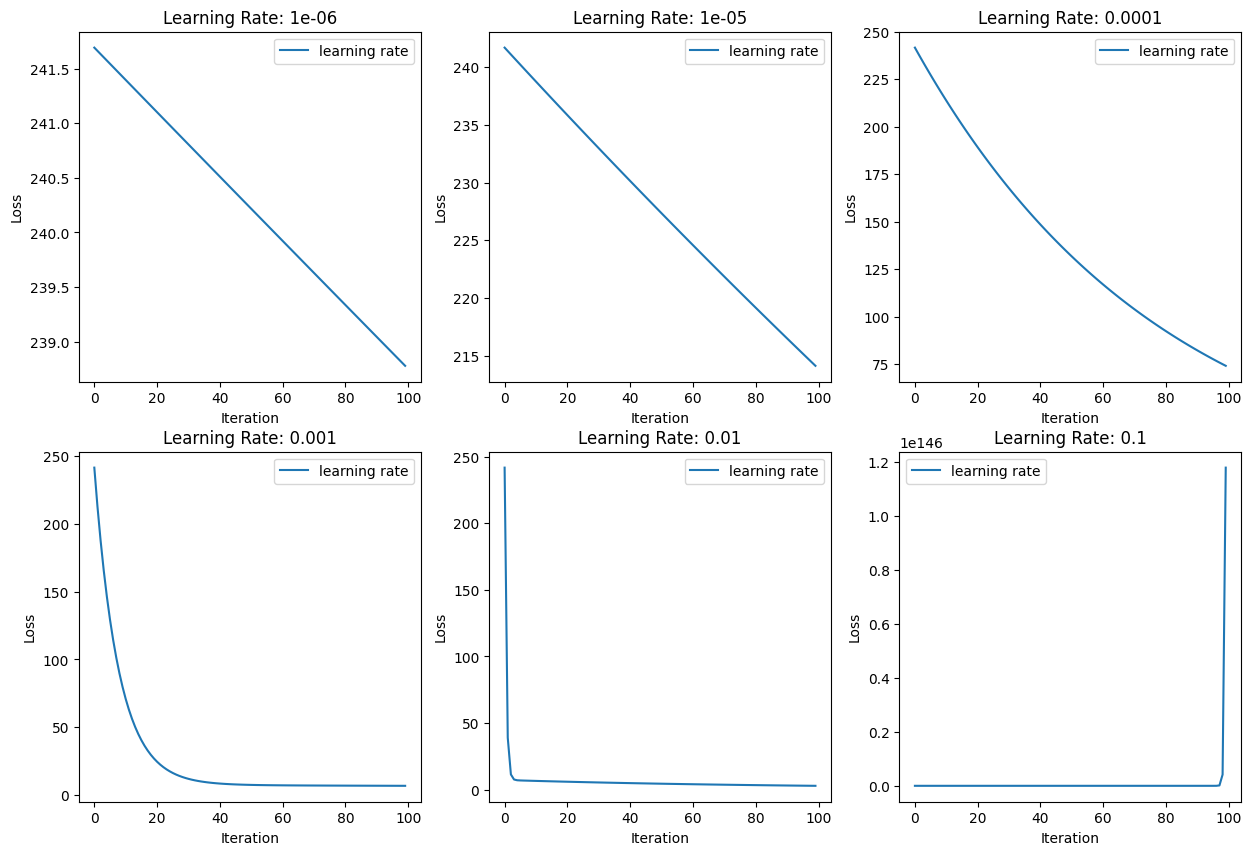

In [51]:
learning_rates = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
n_iterations = 100

plt.figure(figsize=(15, 10))

for i, lr in enumerate(learning_rates):
    theta = np.zeros(2)
    loss_history = []
    
    for iteration in range(n_iterations):
        y_pred = X_bias @ theta
        loss = (1/N) * np.sum((y_pred - y) ** 2)
        loss_history.append(loss)

        gradient = (2/N) * X_bias.T @ (y_pred - y)
        theta = theta - lr * gradient

    plt.subplot(2, 3, i+1)
    plt.plot(loss_history, label=f'learning rate')
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title(f'Learning Rate: {lr}')
    plt.legend()

What happens when the learning rate is too small? Too large? Is there an optimal value in this range?

If the learning rate is too small, the model converges correctly but extremely slowly, requiring a massive number of iterations. If the learning rate is too large, the algorithm diverges -it fails to find the minimum and the error grows to infinity. In the tested range the optimal value proved to be 0.01, which ensured the fastest and most stable convergence in just a few iterations.

### 8. Explore Training Duration
Set `num_epochs` to larger values like 100 or 1000 and observe the training process:
- Does the loss continue to decrease throughout training, or does it plateau?
- At what point does the model effectively converge?
- Plot the loss curve for the extended training and identify where diminishing returns begin
- Calculate how close your final weights are to the true weights after different numbers of epochs

This exercise helps you understand when to stop training to avoid wasting computational resources.


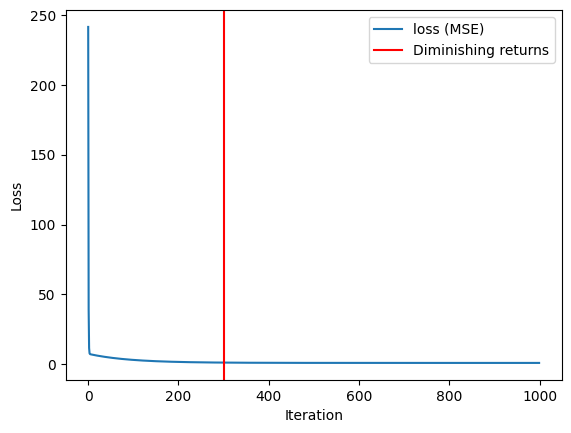

Epoch 10: bias=0.6735 (diff=4.3265), weight=2.6519 (diff=0.6519)
Epoch 50: bias=1.5795 (diff=3.4205), weight=2.5128 (diff=0.5128)
Epoch 100: bias=2.4622 (diff=2.5378), weight=2.3771 (diff=0.3771)
Epoch 300: bias=4.3101 (diff=0.6899), weight=2.0931 (diff=0.0931)
Epoch 1000: bias=5.1967 (diff=0.1967), weight=1.9569 (diff=0.0431)


In [52]:
lr = 0.01
n_iterations = 1000
theta = np.zeros(2)
loss_history = []

epochs_to_check = [10, 50, 100, 300, 1000]
weights_history = []

for iteration in range(1, n_iterations + 1):
    y_pred = X_bias @ theta
    loss = (1/N) * np.sum((y_pred - y) ** 2)
    loss_history.append(loss)

    gradient = (2/N) * X_bias.T @ (y_pred - y)
    theta = theta - lr * gradient

    if iteration in epochs_to_check:
        weights_history.append((iteration, theta.copy()))

plt.plot(range(n_iterations), loss_history, label="loss (MSE)")
plt.axvline(x=300, color='red', label='Diminishing returns')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.show()


for epoch, weights in weights_history:
    bias_diff = abs(bias - weights[0])
    weight_diff = abs(weight - weights[1])
    print(f"Epoch {epoch}: bias={weights[0]:.4f} (diff={bias_diff:.4f}), weight={weights[1]:.4f} (diff={weight_diff:.4f})")


### 9. Visualize the Loss Landscape
Create a visualization of the loss function across different weight values:
- Generate a grid of weight values
- Calculate the loss at each point in this grid
- Create a contour plot showing the "landscape" of the loss function
- Mark your initial weights, final weights, and the true weights on this plot

This visualization will help you understand the shape of the objective function you're optimizing and how gradient descent navigates this landscape to find the minimum.


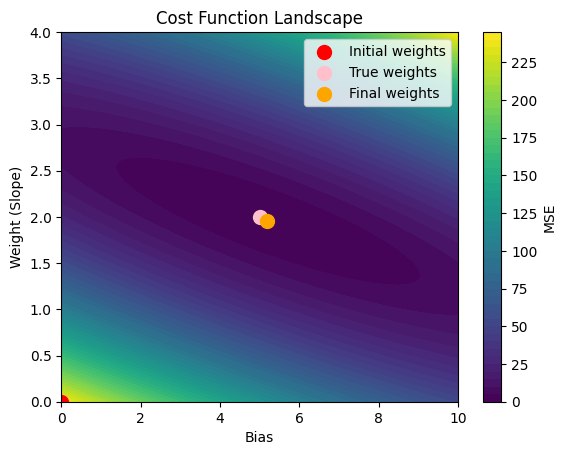

In [83]:
bias_values = np.linspace(0, 10, 100)
weight_values = np.linspace(0, 4, 100) 

loss_matrix = np.zeros((100, 100))

for i in range(len(weight_values)):      
    for j in range(len(bias_values)):  
        w = weight_values[i]
        b = bias_values[j]
        
        y_pred = b + w * X.flatten()
        
        mse = np.mean((y_pred - y) ** 2)
        loss_matrix[i, j] = mse


plt.contourf(bias_values, weight_values, loss_matrix, levels=50)
plt.colorbar(label='MSE')


plt.scatter(0, 0, color='red', s=100, label='Initial weights')

plt.scatter(bias, weight, color='pink', s=100, label='True weights')

plt.scatter(theta[0], theta[1], color='orange', s=100, label='Final weights')

plt.xlabel('Bias')
plt.ylabel('Weight (Slope)')
plt.title('Cost Function Landscape')
plt.legend()
plt.show()


### 10. Analytical Solution
For linear regression, the closed-form solution is 

$$\widehat{\mathbf{w}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$

Compare the parameters and final MSE you get via gradient descent with those from the analytical solution. Are they similar?

In [89]:
X_T_X = X_bias.T @ X_bias
X_T_X_inv = np.linalg.inv(X_T_X) #inalg.inv- macierz odwrotna
theta_a = X_T_X_inv @ X_bias.T @ y
y_pred_a = X_bias @ theta_a
mse_a = np.mean((y_pred_a - y) ** 2)

print(f"True parameters (bias, weight): ({bias:.4f}, {weight:.4f})")
print(f"Estimated parameters (bias, weight) - gradient descent: ({theta[0]:.4f}, {theta[1]:.4f}) | MSE: {loss_history[-1]:.4f}")
print(f"Estimated parameters (bias, weight) - analytical solution: ({theta_a[0]:.4f}, {theta_a[1]:.4f}) | MSE: {mse_a:.4f}")

True parameters (bias, weight): (5.0000, 2.0000)
Estimated parameters (bias, weight) - gradient descent: (5.1967, 1.9569) | MSE: 0.8067
Estimated parameters (bias, weight) - analytical solution: (5.2151, 1.9540) | MSE: 0.8066
